# Generalized alphaD-only eigenvalue-evolution notebook

This notebook is the alphaD-only counterpart to the strength-emulator animation notebook. It is designed for runs produced by `main_only_alphaD_gpt.py`.

Because the alphaD-only emulator has no reconstructed strength function, the animation focuses on:
- parameter-space projection
- predicted vs true `alphaD`
- eigenvalue evolution along a chosen sweep
- the scalar quantity derived from eigenvalues, depending on `alphaD_mode`


In [1]:
import json
from pathlib import Path

import numpy as np
import tensorflow as tf

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LogNorm

import helper_gpt

plt.rcParams.update({"font.size": 14})
matplotlib.rcParams["animation.embed_limit"] = 200


## Configuration

In [2]:
# --- Paths ---
RUN_DIR = Path("runs_em2")              # directory created by main_only_alphaD_gpt.py
BEST_PARAMS_FILE = RUN_DIR / "best_params_global.txt"
RUN_SUMMARY_FILE = RUN_DIR / "run_summary.json"

# --- Dataset locations ---
STRENGTH_DIR = "../dipoles_data_all/total_strength/"
ALPHAD_DIR = "../dipoles_data_all/total_alphaD/"

# Optional overrides
STRENGTH_REGEX = None
ALPHAD_REGEX = None
FILTER_RANGES = None
CENTRAL_POINT = None

# --- Slice selection ---
SWEEP_PARAM = None
FIXED_VALUES = {}
X_PARAM = None
Y_PARAM = None
MATCH_TOL = 1e-6
ALLOWED_SLICE_DRIFT = None

# --- Animation ---
FPS = 1.5
INTERVAL_MS = 700
OUTPUT_MP4 = "animate_alphaD_only_eigenvalue_evolution_generalized.mp4"


## Load run metadata and dataset

In [3]:
with open(RUN_SUMMARY_FILE, "r") as f:
    run_summary = json.load(f)

args = run_summary["args"]
config_dict = run_summary["config"]

strength_regex = STRENGTH_REGEX or args.get("strength_regex") or r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out"
alphaD_regex = ALPHAD_REGEX or args.get("alphaD_regex")
filter_ranges = FILTER_RANGES if FILTER_RANGES is not None else args.get("filter_ranges")
central_point = CENTRAL_POINT if CENTRAL_POINT is not None else args.get("central_point")

dataset = helper_gpt.load_generic_alphaD_dataset(
    strength_dir=STRENGTH_DIR,
    alphaD_dir=ALPHAD_DIR,
    strength_regex=strength_regex,
    alphaD_regex=alphaD_regex,
    filter_ranges=filter_ranges,
    central_point=central_point,
)

params = np.loadtxt(BEST_PARAMS_FILE).astype(np.float32)
config = helper_gpt.AlphaDOnlyConfig(
    n=int(config_dict["n"]),
    n_params=int(config_dict["n_params"]),
    ansatz=config_dict["ansatz"],
    alphaD_mode=config_dict["alphaD_mode"],
)

param_names = list(dataset.param_names)
param_to_idx = {name: i for i, name in enumerate(param_names)}

if SWEEP_PARAM is None:
    SWEEP_PARAM = param_names[0]
if X_PARAM is None:
    X_PARAM = param_names[0]
if Y_PARAM is None:
    Y_PARAM = param_names[1] if len(param_names) > 1 else param_names[0]

print("Parameter names:", param_names)
print("Central point:", dataset.central_point)
print("Sweep parameter:", SWEEP_PARAM)
print("Projection axes:", X_PARAM, Y_PARAM)
print("alphaD mode:", config.alphaD_mode)


Parameter names: ['p1', 'p2']
Central point: [1.1  2.75]
Sweep parameter: p1
Projection axes: p1 p2
alphaD mode: mid_eigenvalue


## Helper functions

In [4]:
def evaluate_alphaD_only_point(params_np, config, point, central_point):
    params_tf = tf.convert_to_tensor(params_np, dtype=tf.float32)
    point_tf = tf.convert_to_tensor(np.asarray(point, dtype=np.float32)[None, :], dtype=tf.float32)
    central_tf = tf.convert_to_tensor(np.asarray(central_point, dtype=np.float32), dtype=tf.float32)

    M_batch, _ = helper_gpt.build_alphaD_only_matrices(
        params=params_tf,
        config=config,
        param_values=point_tf,
        central_point=central_tf,
    )

    eigvals, eigvecs = tf.linalg.eigh(M_batch[0])
    alpha_pred = helper_gpt.alphaD_from_eigenvalues_batch(
        eigvals[None, :],
        mode=config.alphaD_mode,
    )[0]

    return {
        "eigvals": eigvals.numpy(),
        "alphaD_pred": float(alpha_pred.numpy()),
    }

def relative_alphaD_error(pred, true):
    return np.abs(pred - true) / np.maximum(np.abs(true), 1e-12)

def choose_slice_points(param_values, param_names, sweep_param, fixed_values, tol=MATCH_TOL):
    values = np.asarray(param_values, dtype=float)
    sweep_idx = param_names.index(sweep_param)

    fixed = {}
    for name in param_names:
        if name == sweep_param:
            continue
        if name in fixed_values:
            fixed[name] = float(fixed_values[name])
        else:
            fixed[name] = float(dataset.central_point[param_names.index(name)])

    distances = np.zeros(len(values), dtype=float)
    exact_mask = np.ones(len(values), dtype=bool)

    for name, target in fixed.items():
        idx = param_names.index(name)
        delta = np.abs(values[:, idx] - target)
        distances += delta**2
        exact_mask &= delta <= tol

    if np.any(exact_mask):
        chosen = np.where(exact_mask)[0]
    else:
        if ALLOWED_SLICE_DRIFT is not None:
            chosen = np.where(np.sqrt(distances) <= ALLOWED_SLICE_DRIFT)[0]
            if len(chosen) == 0:
                chosen = np.argsort(distances)[:max(3, min(12, len(values)))]
        else:
            chosen = np.argsort(distances)[:max(3, min(12, len(values)))]

    chosen = sorted(chosen, key=lambda i: values[i, sweep_idx])
    return chosen, fixed


## Precompute predictions

In [5]:
pred_cache = []
alphaD_pred_all = np.zeros(len(dataset.alphaD_values), dtype=float)

for i, point in enumerate(dataset.param_values):
    result = evaluate_alphaD_only_point(
        params_np=params,
        config=config,
        point=point,
        central_point=dataset.central_point,
    )
    pred_cache.append(result)
    alphaD_pred_all[i] = result["alphaD_pred"]

alphaD_err_all = relative_alphaD_error(alphaD_pred_all, dataset.alphaD_values)

slice_indices, used_fixed = choose_slice_points(
    param_values=dataset.param_values,
    param_names=param_names,
    sweep_param=SWEEP_PARAM,
    fixed_values=FIXED_VALUES,
)

slice_points = dataset.param_values[slice_indices]
print("Slice uses", len(slice_indices), "frames")
print("Fixed values used:", used_fixed)


Slice uses 11 frames
Fixed values used: {'p2': 2.75}


## Quick diagnostics

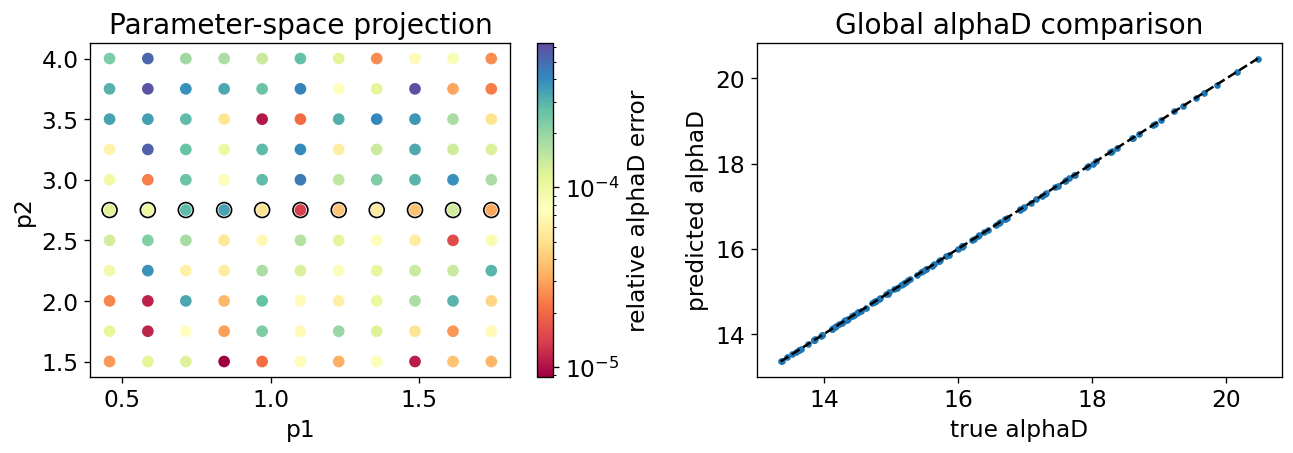

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

proj_x = dataset.param_values[:, param_to_idx[X_PARAM]]
proj_y = dataset.param_values[:, param_to_idx[Y_PARAM]]

sc = axes[0].scatter(proj_x, proj_y, c=alphaD_err_all, cmap="Spectral", norm=LogNorm())
axes[0].scatter(
    slice_points[:, param_to_idx[X_PARAM]],
    slice_points[:, param_to_idx[Y_PARAM]],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=80,
)
axes[0].set_xlabel(X_PARAM)
axes[0].set_ylabel(Y_PARAM)
axes[0].set_title("Parameter-space projection")
fig.colorbar(sc, ax=axes[0], label="relative alphaD error")

axes[1].plot(dataset.alphaD_values, alphaD_pred_all, ".")
lims = [
    min(np.min(dataset.alphaD_values), np.min(alphaD_pred_all)),
    max(np.max(dataset.alphaD_values), np.max(alphaD_pred_all)),
]
axes[1].plot(lims, lims, "k--")
axes[1].set_xlabel("true alphaD")
axes[1].set_ylabel("predicted alphaD")
axes[1].set_title("Global alphaD comparison")
plt.tight_layout()
plt.show()


## Build animation

In [7]:
fig, (ax_scalar, ax_grid, ax_eigs) = plt.subplots(
    3, 1, figsize=(8, 14), dpi=150,
    gridspec_kw={"height_ratios": [1.0, 1.0, 1.2]}
)
fig.subplots_adjust(top=0.93, hspace=0.35)
fig.suptitle(f"alphaD-only emulator evolution | sweep {SWEEP_PARAM}", fontsize=16)

proj_x = dataset.param_values[:, param_to_idx[X_PARAM]]
proj_y = dataset.param_values[:, param_to_idx[Y_PARAM]]

sc = ax_grid.scatter(proj_x, proj_y, c=alphaD_err_all, cmap="Spectral", norm=LogNorm(), marker="s")
marker, = ax_grid.plot([], [], "kX", markersize=10, markeredgewidth=2)
ax_grid.set_xlabel(X_PARAM)
ax_grid.set_ylabel(Y_PARAM)
ax_grid.set_title("Parameter-space projection")
fig.colorbar(sc, ax=ax_grid, label="relative alphaD error")

sweep_values_hist = []
scalar_truth_hist = []
scalar_pred_hist = []
eig_hist = []

def init():
    return []

def animate(frame_idx):
    ds_idx = slice_indices[frame_idx]
    point = dataset.param_values[ds_idx]
    pred = pred_cache[ds_idx]
    truth_val = dataset.alphaD_values[ds_idx]
    sweep_val = float(point[param_to_idx[SWEEP_PARAM]])

    sweep_values_hist.append(sweep_val)
    scalar_truth_hist.append(truth_val)
    scalar_pred_hist.append(pred["alphaD_pred"])
    eig_hist.append(pred["eigvals"])

    ax_scalar.cla()
    ax_scalar.plot(sweep_values_hist, scalar_truth_hist, "k.-", label="true alphaD")
    ax_scalar.plot(sweep_values_hist, scalar_pred_hist, "r.--", label="pred alphaD")
    ax_scalar.set_xlabel(SWEEP_PARAM)
    ax_scalar.set_ylabel("alphaD")
    title_bits = [f"{name}={point[param_to_idx[name]]:.4g}" for name in param_names]
    ax_scalar.set_title(" | ".join(title_bits))
    ax_scalar.legend(loc="best")
    ax_scalar.grid(True)

    marker.set_data([point[param_to_idx[X_PARAM]]], [point[param_to_idx[Y_PARAM]]])

    ax_eigs.cla()
    eig_arr = np.array(eig_hist)
    sweep_arr = np.array(sweep_values_hist)
    for k in range(eig_arr.shape[1]):
        ax_eigs.plot(sweep_arr, eig_arr[:, k], "o-", markersize=4)
    ax_eigs.set_xlabel(SWEEP_PARAM)
    ax_eigs.set_ylabel("Eigenvalue")
    ax_eigs.set_title(f"Eigenvalue evolution ({config.alphaD_mode})")
    ax_eigs.grid(True)

    return []

ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(slice_indices),
    interval=INTERVAL_MS,
    repeat=False,
)

plt.close(fig)
ani


## Save MP4

In [8]:
writer = animation.FFMpegWriter(fps=FPS)
ani.save(OUTPUT_MP4, writer=writer)
print("Saved:", OUTPUT_MP4)


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'